In [1]:
from simulator import Config, Simulator

config = Config()
config.NODE_POWER_W = 0.00703 # Node power consumption in W
simulator = Simulator(config)

# CSV including time series data for production (G(h) in kWh, and Temperature in °C)
production_data = "raw-data/Benidorm.csv"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from visualization import (
    get_config_trace,
    plot_soc,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc,
    plot_full_soc_analysis,
    plot_pareto_front,
)


## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability
6. Compute Optimal solutions (Pareto Front)
7. Compute scores of the solutions in Pareto front

In [3]:
# Run the full simulation
results = simulator.run_full_simulation(production_data)

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!


## Design space

In [4]:
df_design = simulator.build_design_space()
df_design

,panel_area_m2,battery_capacity_Ah,eta_PMU
0,0.000100,0.011,0.70
1,0.000100,0.011,0.75
2,0.000100,0.011,0.80
3,0.000100,0.011,0.85
4,0.000100,0.011,0.87
...,...,...,...
3339,0.061102,3.200,0.85
3340,0.061102,3.200,0.87
3341,0.061102,3.200,0.90
3342,0.061102,3.200,0.95


In [5]:
## Explore Results

In [6]:
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
0,0.000400,0.35,0.98,8760,0,1707,0.921424,0.104766,9.396243,23.048913,8760,0,0.525,0.014367,0.0,0.194863,-13.652670,2.488404
1,0.000400,0.36,0.98,8760,0,1707,0.923607,0.101856,9.396243,23.048913,8760,0,0.720,0.014367,0.0,0.194863,-13.652670,2.485268
2,0.000400,0.50,0.95,8760,0,1539,0.911703,0.133552,9.712317,21.460577,8760,0,0.500,0.013446,0.0,0.175685,-11.748260,2.480794
3,0.000400,0.40,0.98,8760,0,1707,0.931246,0.091671,9.396243,23.048913,8760,0,0.600,0.014367,0.0,0.194863,-13.652670,2.472725
4,0.000400,0.42,0.98,8760,0,1707,0.934520,0.087305,9.396243,23.048913,8760,0,0.630,0.014367,0.0,0.194863,-13.652670,2.466453
5,0.000400,0.55,0.95,8760,0,1539,0.919730,0.121410,9.712317,21.460577,8760,0,1.000,0.013446,0.0,0.175685,-11.748260,2.465115
6,0.000625,0.25,0.85,8760,0,1943,0.925997,0.076319,10.655196,29.209420,8760,0,0.250,0.017461,0.0,0.221804,-18.554224,2.460687
7,0.001000,0.25,0.70,8760,0,1943,0.910146,0.091319,12.792601,33.311301,8760,0,0.250,0.019370,0.0,0.221804,-20.518700,2.454540
8,0.000625,0.50,0.80,8760,0,1636,0.918180,0.119837,11.354855,25.538623,8760,0,0.500,0.015378,0.0,0.186758,-14.183768,2.454341
9,0.000400,0.50,0.98,8760,0,1707,0.944997,0.073336,9.396243,23.048913,8760,0,0.500,0.014367,0.0,0.194863,-13.652670,2.441367


## Best combinations

In [7]:
print(summary["score"].max())
best_configs = summary[summary["score"] == summary["score"].max()]

print(len(best_configs))

for config_idx, config_row in best_configs.iterrows():
    print()
    print(config_row[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

2.4884037134708876
1

panel_area_m2    0.000400
C_batt_Ah        0.350000
eta_PMU          0.980000
score            2.488404
Name: 0, dtype: float64


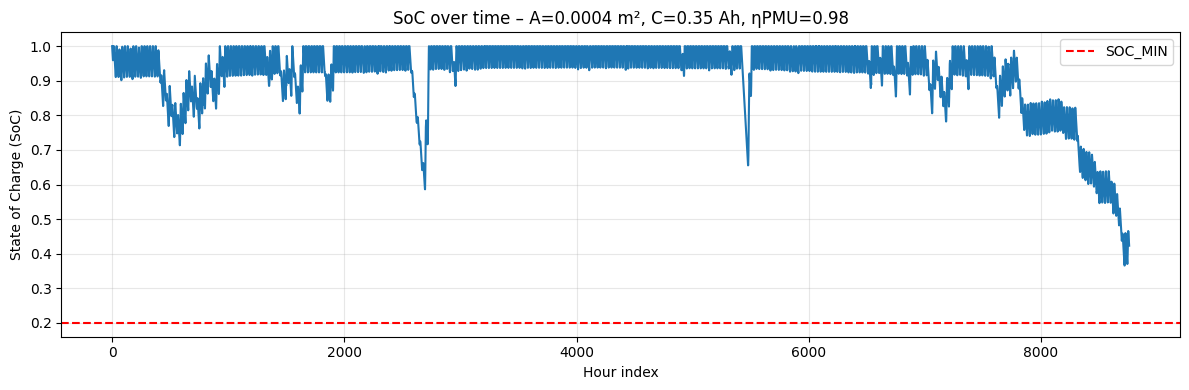

In [8]:
for _, cfg in best_configs.iterrows():
    config_soc = df_soc[
        (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
        (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
        (df_soc['eta_PMU'] == cfg['eta_PMU'])
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(config_soc['hour_index'], config_soc['SoC'])
    plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
    plt.xlabel('Hour index')
    plt.ylabel('State of Charge (SoC)')
    plt.title(
        f"SoC over time – A={cfg['panel_area_m2']} m², "
        f"C={cfg['C_batt_Ah']} Ah, ηPMU={cfg['eta_PMU']}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Plot best configurations

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

In [9]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_Ah",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_Ah": "Battery (Ah)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## Score Distribution Histogram

In [10]:
summary_plot = summary[summary["score"] > 0].copy()

fig = px.histogram(
    summary_plot,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution (score > 0)",
    bargap=0.05
)

fig.show()

## Score at Maximum PMU Efficiency (not best configs)

In [11]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_Ah",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (Ah)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Summary statistics

In [12]:
print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")
print(f"Viable configurations (score > 0): {len(summary[summary['score'] > 0])}")
print(f"Configurations with failures: {len(summary[summary['failure_hours'] > 0])}")
print("Configuration with I_req_max > I_batt_max):",
      len(summary[summary["I_req_max_A"] > summary["I_batt_max_A"]]))



=== Simulation Summary ===
Total configurations evaluated: 3344
Best score achieved: 2.4884
Configurations with best score: 1
Viable configurations (score > 0): 2470
Configurations with failures: 874
Configuration with I_req_max > I_batt_max): 835


## Invalidad configs due to < SoC_min

In [13]:
invalid_soc = summary[summary["failure_hours"] > 0][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "failure_hours",
    "autonomy_hours",
    "I_batt_max_A",
    "I_req_max_A"
]].sort_values("failure_hours", ascending=False)

invalid_soc


,panel_area_m2,C_batt_Ah,eta_PMU,failure_hours,autonomy_hours,I_batt_max_A,I_req_max_A
2663,0.000100,0.011,0.70,7284,10,0.0110,0.002714
2707,0.000100,0.105,0.70,7248,40,0.1575,0.002714
2665,0.000100,0.120,0.70,7244,44,0.2400,0.002714
2673,0.000100,0.250,0.70,7198,90,0.2500,0.002714
3267,0.000100,0.350,0.70,7165,123,0.5250,0.002714
...,...,...,...,...,...,...,...
3068,0.025000,0.120,0.98,12,5466,0.2400,1.012448
2825,0.010057,0.120,0.98,12,5466,0.2400,0.406175
3124,0.000400,0.250,0.98,11,8709,0.2500,0.014367
2588,0.000400,0.880,0.90,7,8719,1.7600,0.011977


## Invalid configs due I_req > I_batt_max

In [14]:
invalid_peak = summary[
    summary["I_req_max_A"] > summary["I_batt_max_A"]
][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "I_req_max_A",
    "I_batt_max_A",
    "failure_hours",
    "autonomy_hours"
]].sort_values("I_req_max_A", ascending=False)

invalid_peak


,panel_area_m2,C_batt_Ah,eta_PMU,I_req_max_A,I_batt_max_A,failure_hours,autonomy_hours
2648,0.061102,0.011,0.98,2.477193,0.0110,3023,19
2631,0.061102,0.105,0.98,2.477193,0.1575,18,5460
2349,0.061102,1.400,0.98,2.477193,2.0000,0,8760
2689,0.061102,0.120,0.98,2.477193,0.2400,12,5466
2453,0.061102,2.500,0.98,2.477193,1.5000,0,8760
...,...,...,...,...,...,...,...
3180,0.000400,0.011,0.95,0.013446,0.0110,3635,17
2551,0.000625,0.011,0.75,0.013427,0.0110,3853,16
3181,0.000400,0.011,0.90,0.011977,0.0110,3818,17
2550,0.000625,0.011,0.70,0.011608,0.0110,3944,16


In [15]:
summary["autonomy_hours"].describe()


count    3344.000000
mean     7316.655203
std      2800.553506
min        10.000000
25%      8310.500000
50%      8760.000000
75%      8760.000000
max      8760.000000
Name: autonomy_hours, dtype: float64

In [16]:
summary.sort_values("autonomy_hours").head(5)


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
2663,0.0001,0.011,0.70,8760,7284,1,0.217424,0.050561,16.653137,0.378610,10,7284,0.011,0.002714,0.831507,0.000114,16.274527,0.0
2988,0.0001,0.011,0.75,8760,7013,1,0.228150,0.074368,15.292989,0.561188,11,7013,0.011,0.002533,0.800571,0.000114,14.731801,0.0
2682,0.0001,0.011,0.80,8760,6734,1,0.242435,0.103726,14.129500,0.781554,12,6734,0.011,0.002375,0.768721,0.000114,13.347945,0.0
2989,0.0001,0.011,0.87,8760,6330,1,0.269341,0.153596,12.763861,1.157682,13,6330,0.011,0.002184,0.722603,0.000114,11.606178,0.0
2681,0.0001,0.011,0.85,8760,6455,1,0.260734,0.138300,13.126565,1.041894,13,6455,0.011,0.002235,0.736872,0.000114,12.084671,0.0


In [17]:
summary.sort_values("autonomy_hours").tail(5)

,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
4,0.0004,0.42,0.98,8760,0,1707,0.934520,0.087305,9.396243,23.048913,8760,0,0.630,0.014367,0.0,0.194863,-13.65267,2.466453
3,0.0004,0.40,0.98,8760,0,1707,0.931246,0.091671,9.396243,23.048913,8760,0,0.600,0.014367,0.0,0.194863,-13.65267,2.472725
2,0.0004,0.50,0.95,8760,0,1539,0.911703,0.133552,9.712317,21.460577,8760,0,0.500,0.013446,0.0,0.175685,-11.74826,2.480794
1,0.0004,0.36,0.98,8760,0,1707,0.923607,0.101856,9.396243,23.048913,8760,0,0.720,0.014367,0.0,0.194863,-13.65267,2.485268
0,0.0004,0.35,0.98,8760,0,1707,0.921424,0.104766,9.396243,23.048913,8760,0,0.525,0.014367,0.0,0.194863,-13.65267,2.488404


In [18]:
# 1) Maximum score configuration
cfg_best = summary.sort_values("score", ascending=False).iloc[0]

# 2) Minimum non-zero score configuration
summary_nonzero = summary[summary["score"] > 0]
cfg_bad = summary_nonzero.sort_values("score", ascending=True).iloc[0]

# 3) Score closest to 0.5 (mid-score representative)
target = 0.5
idx_mid = (summary["score"] - target).abs().idxmin()
cfg_mid = summary.loc[idx_mid]

# 4) Failure case (for comparison)
cfg_fail = summary[summary["score"] == 0].sort_values("score").iloc[0]


print("\n=== BEST SCORE CONFIGURATION ===")
print(cfg_best[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== BAD NON-ZERO SCORE CONFIGURATION ===")
print(cfg_bad[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== MID-SCORE (~0.5) CONFIGURATION ===")
print(cfg_mid[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== FAILURE CASE CONFIGURATION ===")
print(cfg_fail[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])



=== BEST SCORE CONFIGURATION ===
panel_area_m2    0.000400
C_batt_Ah        0.350000
eta_PMU          0.980000
score            2.488404
Name: 0, dtype: float64

=== BAD NON-ZERO SCORE CONFIGURATION ===
panel_area_m2    0.061102
C_batt_Ah        3.200000
eta_PMU          0.980000
score            0.006102
Name: 2469, dtype: float64

=== MID-SCORE (~0.5) CONFIGURATION ===
panel_area_m2    0.061102
C_batt_Ah        1.600000
eta_PMU          0.980000
score            0.507827
Name: 2381, dtype: float64

=== FAILURE CASE CONFIGURATION ===
panel_area_m2    0.000625
C_batt_Ah        1.200000
eta_PMU          0.700000
score            0.000000
Name: 2470, dtype: float64


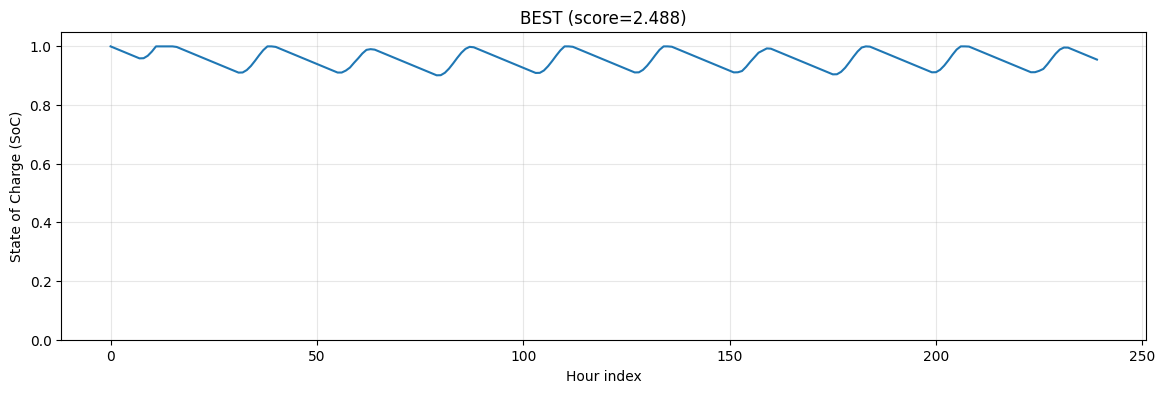

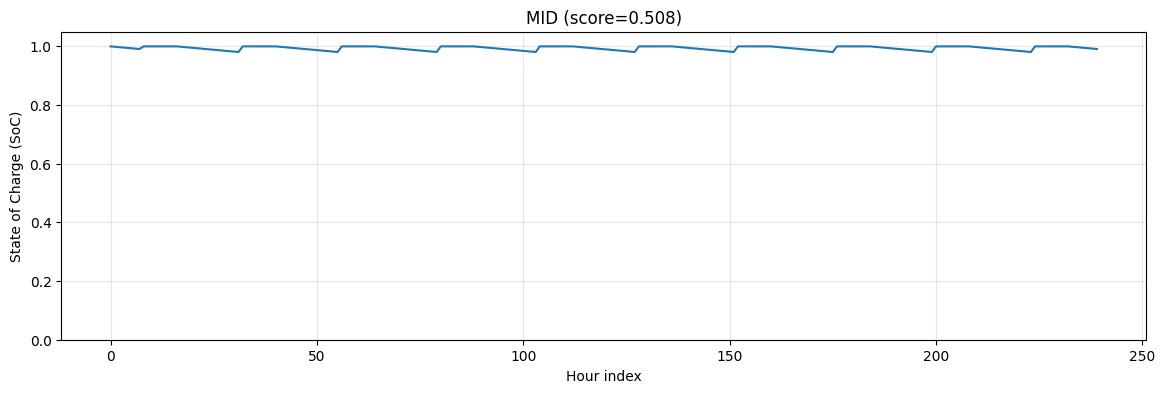

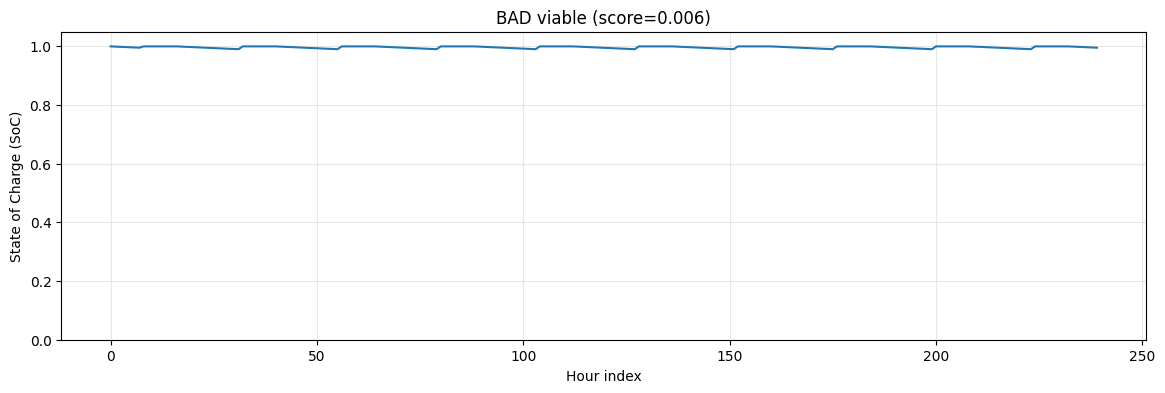

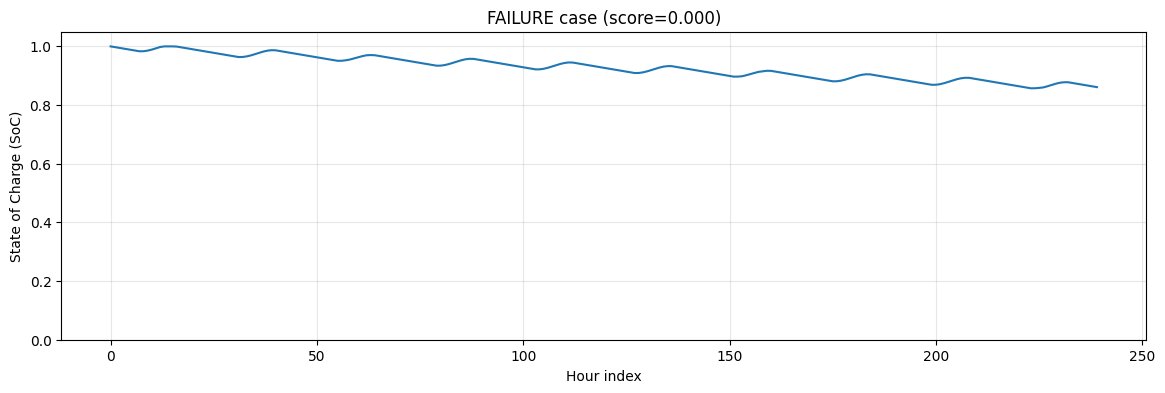

In [19]:
# BEST SCORE
plot_soc(
    df_soc,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    title=f"BEST (score={cfg_best['score']:.3f})"
)

# MID SCORE (~0.5)
plot_soc(
    df_soc,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    title=f"MID (score={cfg_mid['score']:.3f})"
)

# BAD NON-ZERO SCORE
plot_soc(
    df_soc,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    title=f"BAD viable (score={cfg_bad['score']:.3f})"
)

# FAILURE CASE
plot_soc(
    df_soc,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    title=f"FAILURE case (score={cfg_fail['score']:.3f})"
)

In [20]:
from visualization import (
    get_config_trace,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc
)


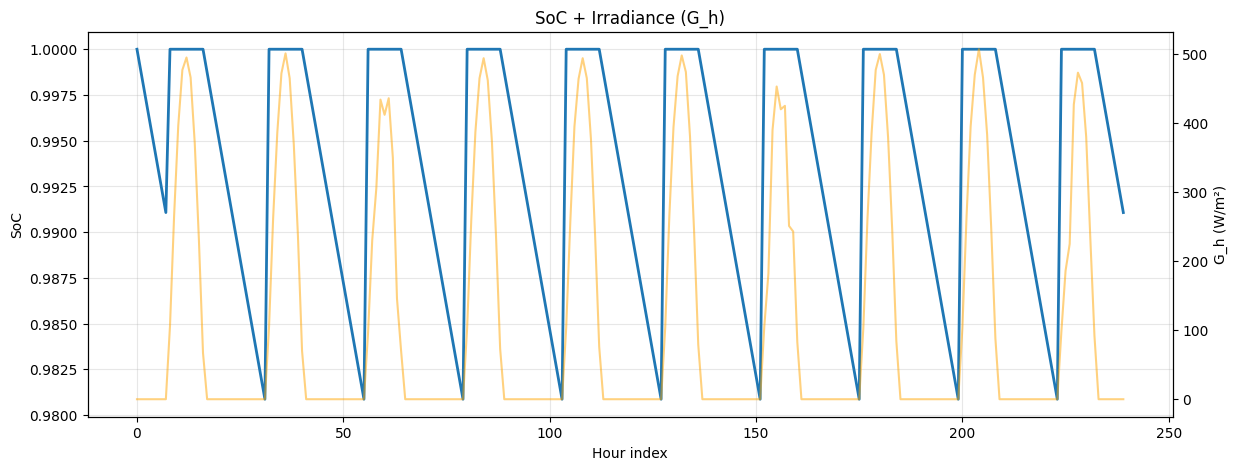

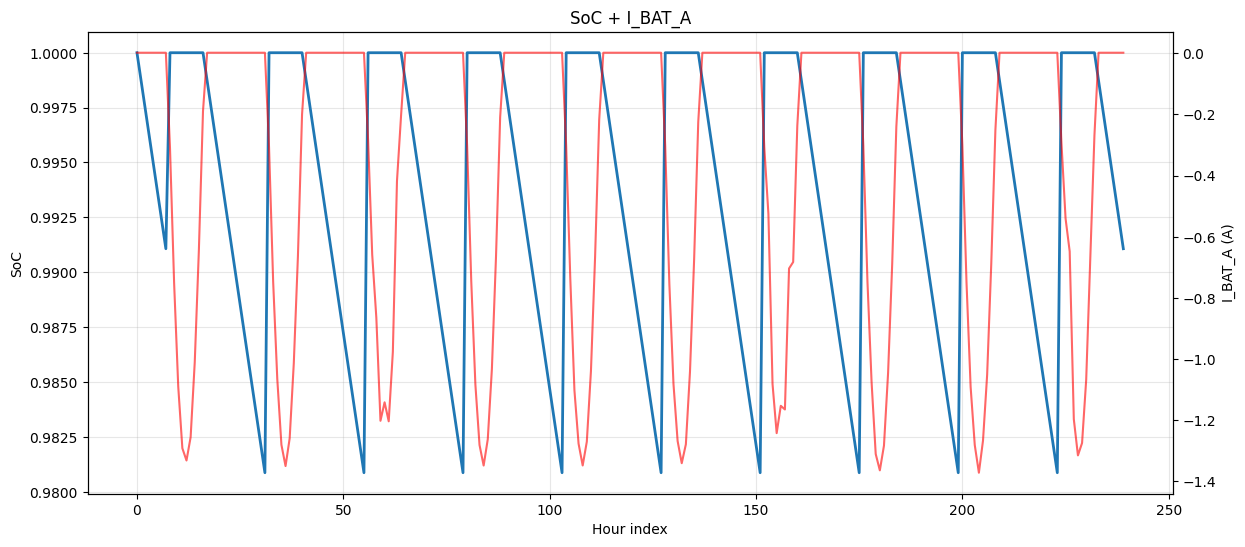

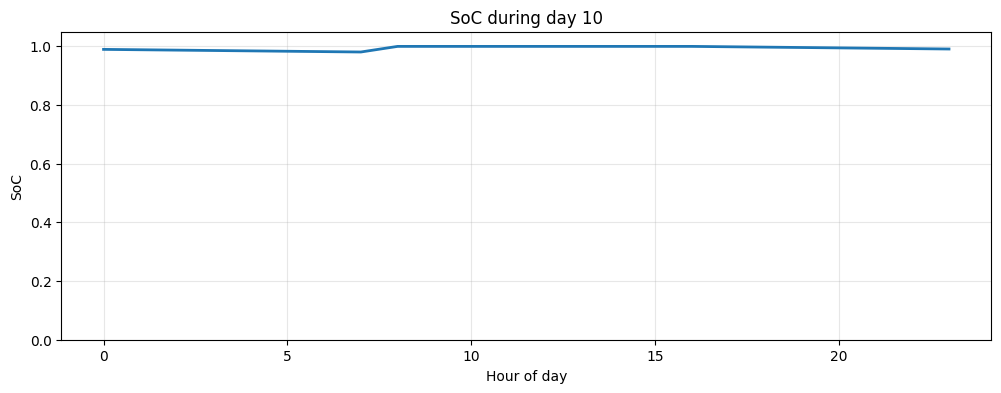

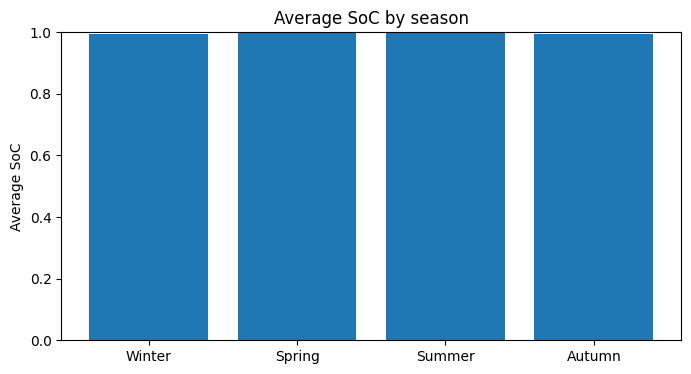

In [21]:
# Choose a configuration, e.g. cfg_mid (score ~0.5)
panel  = cfg_mid["panel_area_m2"]
cap    = cfg_mid["C_batt_Ah"]
eta    = cfg_mid["eta_PMU"]

cfg = get_config_trace(df_soc, panel, cap, eta)

plot_soc_gh(cfg, df_pv, hours=240, title="SoC + Irradiance (G_h)")
plot_soc_ibatt(cfg, hours=240, title="SoC + I_BAT_A")
plot_daily(cfg, day_index=10)
plot_seasonal_soc(cfg)


In [22]:
# Sort all configurations by score
summary_sorted = summary.sort_values("score", ascending=False)

# 1) Best score
cfg_best = summary_sorted.iloc[0]
title_best = f"BEST - Panel: {cfg_best['panel_area_m2']} m², Batería: {cfg_best['C_batt_Ah']} Ah, PMU: {cfg_best['eta_PMU']}, Score: {cfg_best['score']:.3f}"

# 2) BAD non-zero score
cfg_bad = summary_sorted[summary_sorted["score"] > 0].sort_values("score").iloc[0]
title_bad = f"BAD - Panel: {cfg_bad['panel_area_m2']} m², Batería: {cfg_bad['C_batt_Ah']} Ah, PMU: {cfg_bad['eta_PMU']}, Score: {cfg_bad['score']:.3f}"

# 3) MID score (between BAD and BEST)
configs_between = summary_sorted[
    (summary_sorted["score"] > cfg_bad["score"]) &
    (summary_sorted["score"] < cfg_best["score"])
].sort_values("score")
cfg_mid = configs_between.iloc[len(configs_between) // 2]
title_mid = f"MID - Panel: {cfg_mid['panel_area_m2']} m², Batería: {cfg_mid['C_batt_Ah']} Ah, PMU: {cfg_mid['eta_PMU']}, Score: {cfg_mid['score']:.3f}"

# 4) Failure case (for comparison)
cfg_fail = summary_sorted[summary_sorted["score"] == 0].sort_values("score").iloc[0]
title_fail = f"FAIL - Panel: {cfg_fail['panel_area_m2']} m², Batería: {cfg_fail['C_batt_Ah']} Ah, PMU: {cfg_fail['eta_PMU']}, Score: {cfg_fail['score']:.3f}"

print("\nBEST:", cfg_best[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nMID:", cfg_mid[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nBAD:", cfg_bad[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nFAIL:", cfg_fail[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])



BEST: panel_area_m2    0.000400
C_batt_Ah        0.350000
eta_PMU          0.980000
score            2.488404
Name: 0, dtype: float64

MID: panel_area_m2    0.004000
C_batt_Ah        2.300000
eta_PMU          0.700000
score            1.414251
Name: 1234, dtype: float64

BAD: panel_area_m2    0.061102
C_batt_Ah        3.200000
eta_PMU          0.980000
score            0.006102
Name: 2469, dtype: float64

FAIL: panel_area_m2    0.000625
C_batt_Ah        1.200000
eta_PMU          0.700000
score            0.000000
Name: 2470, dtype: float64


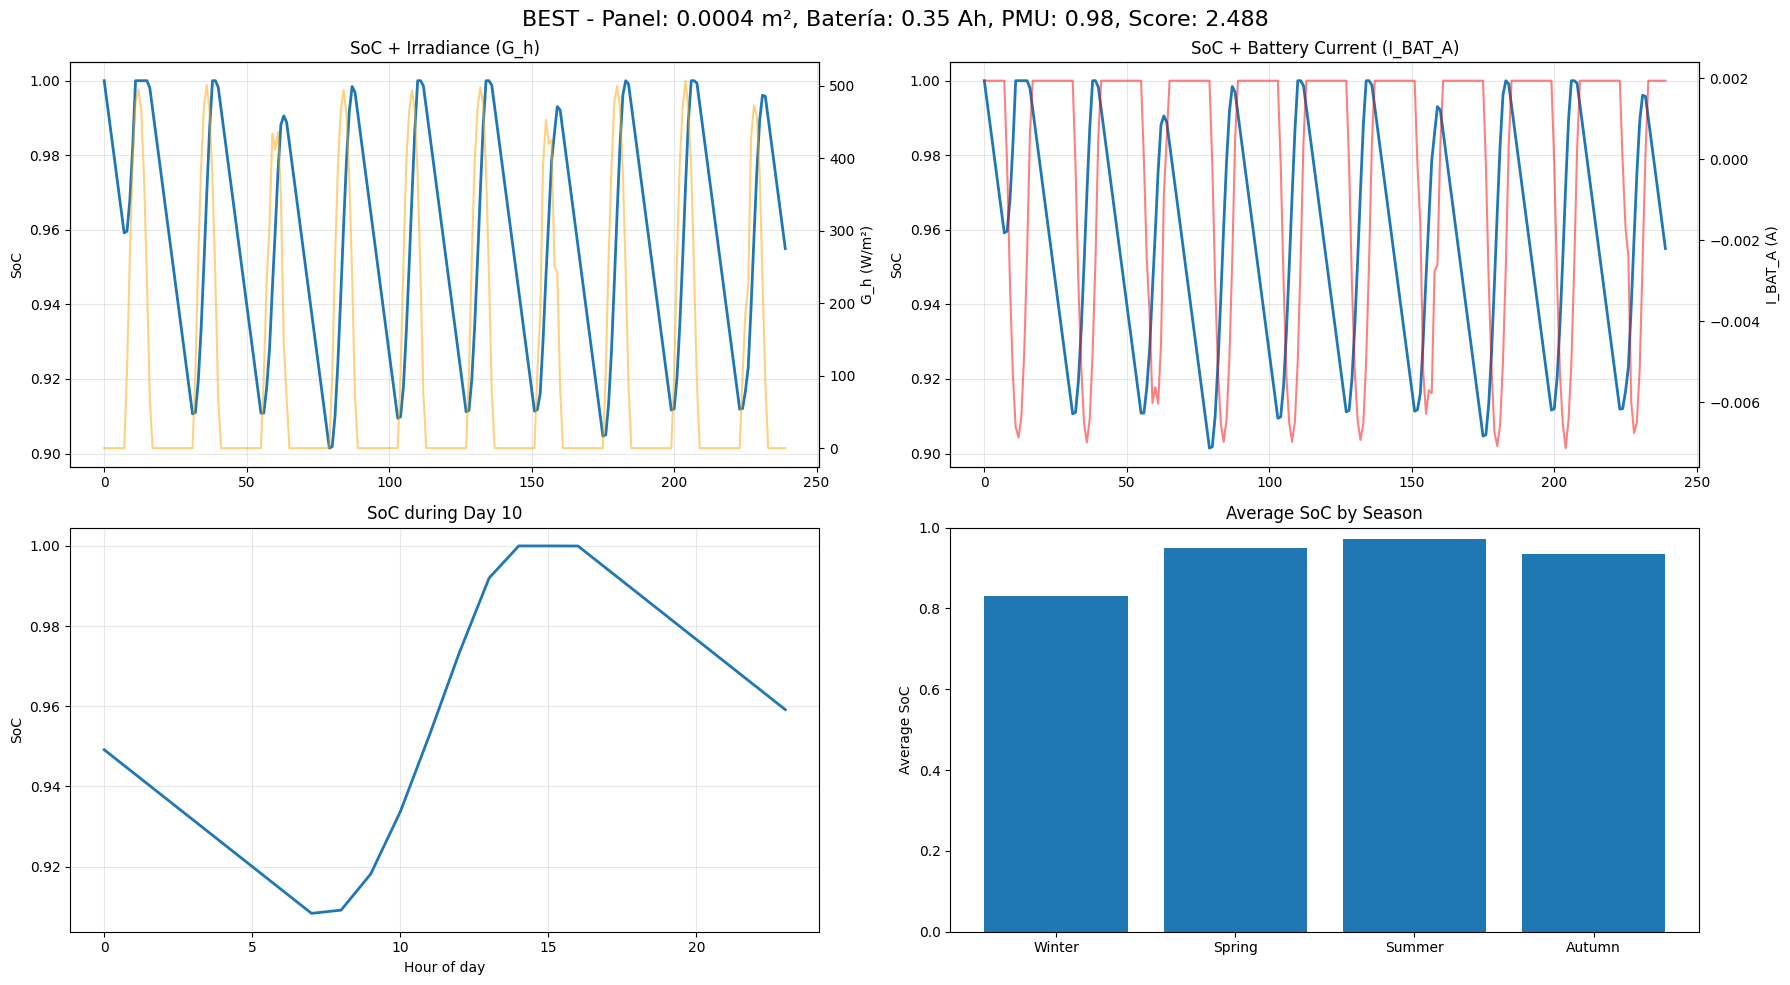

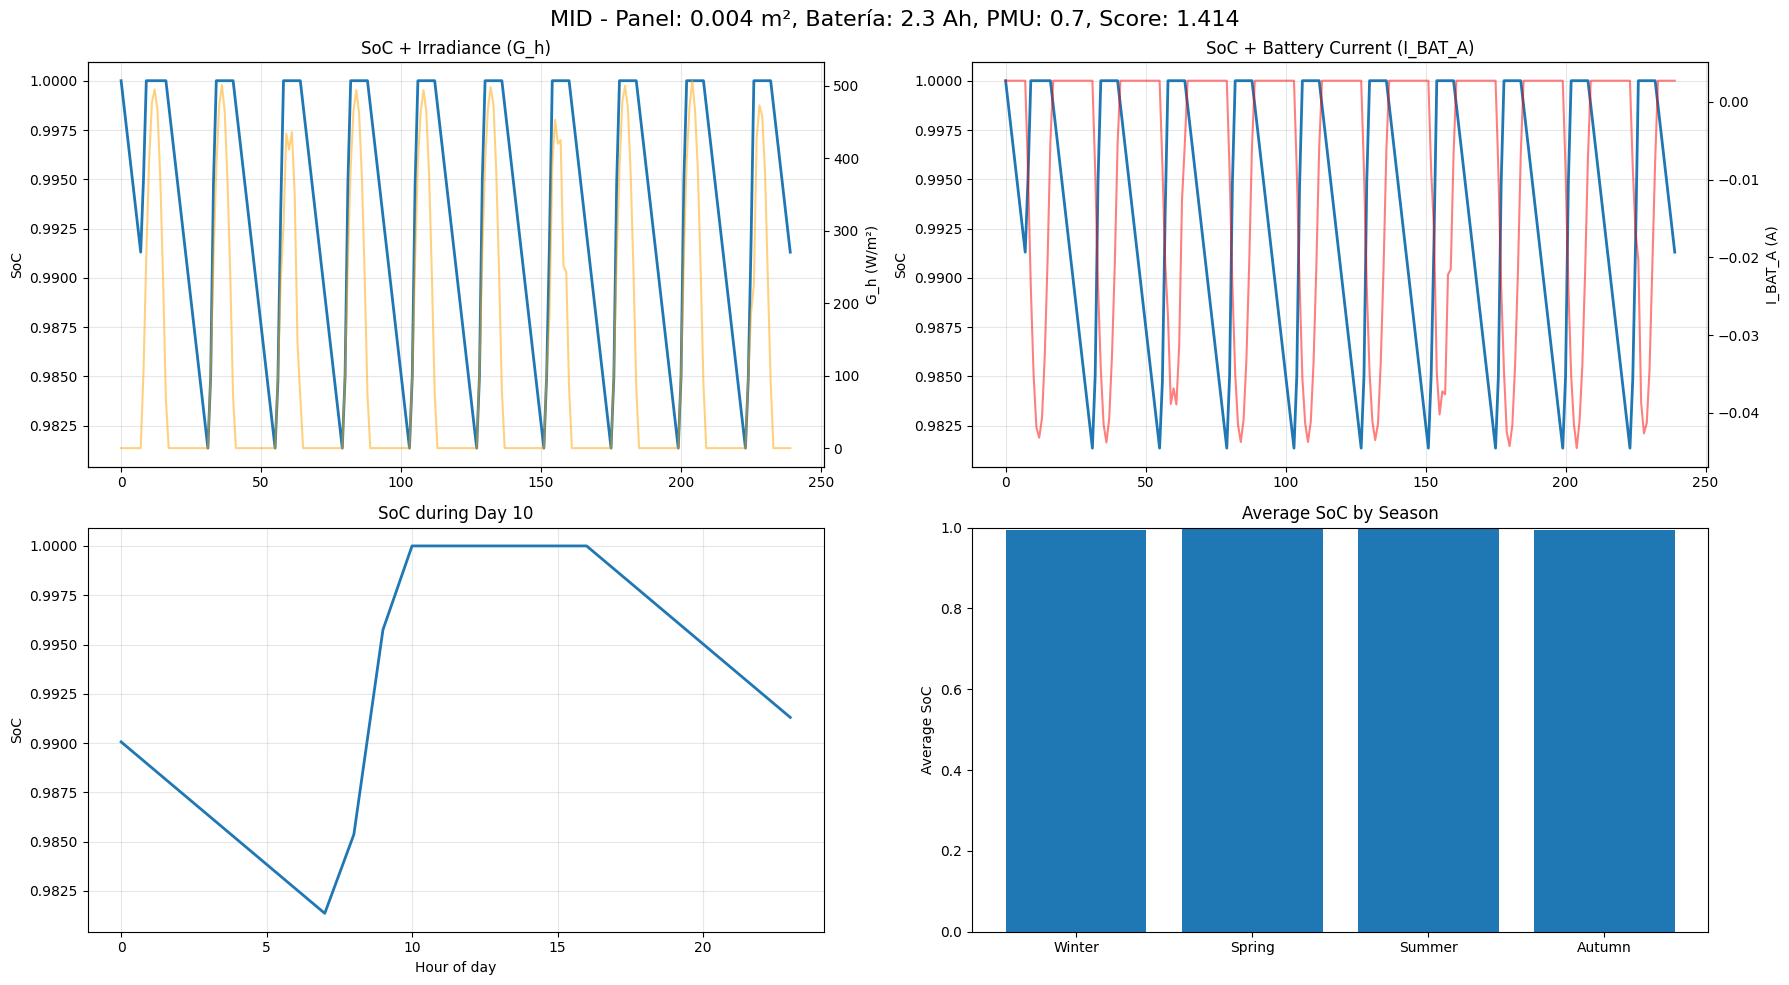

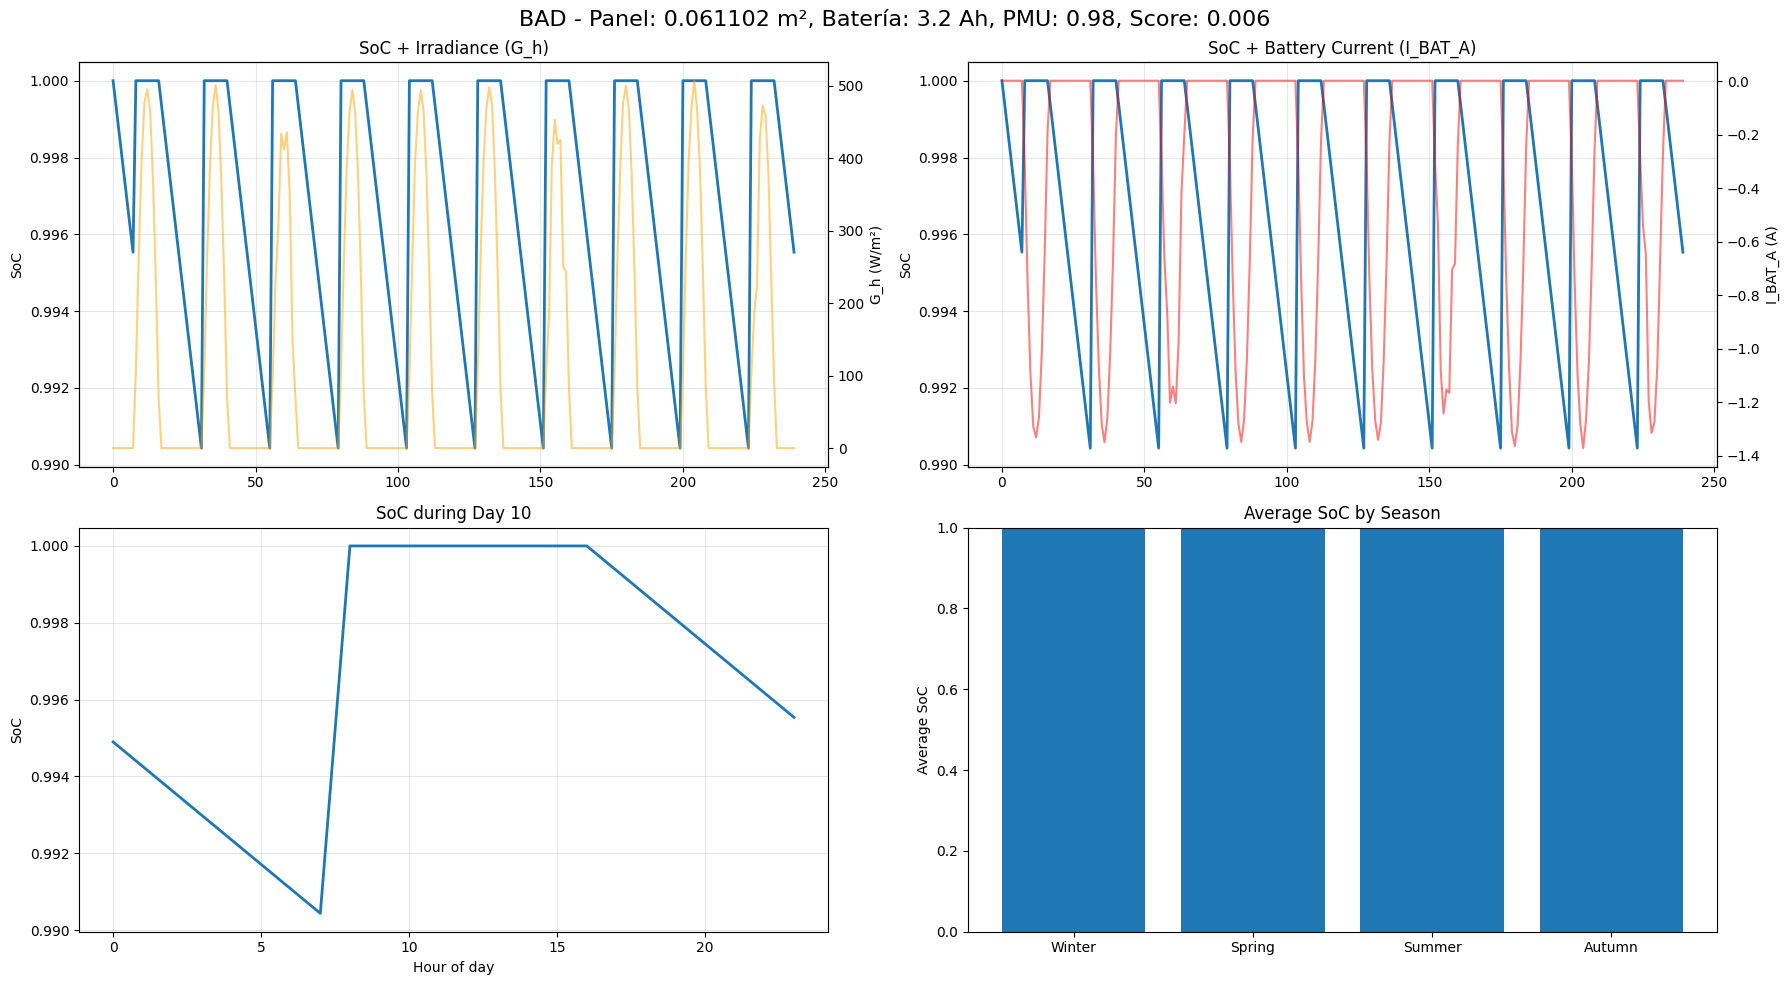

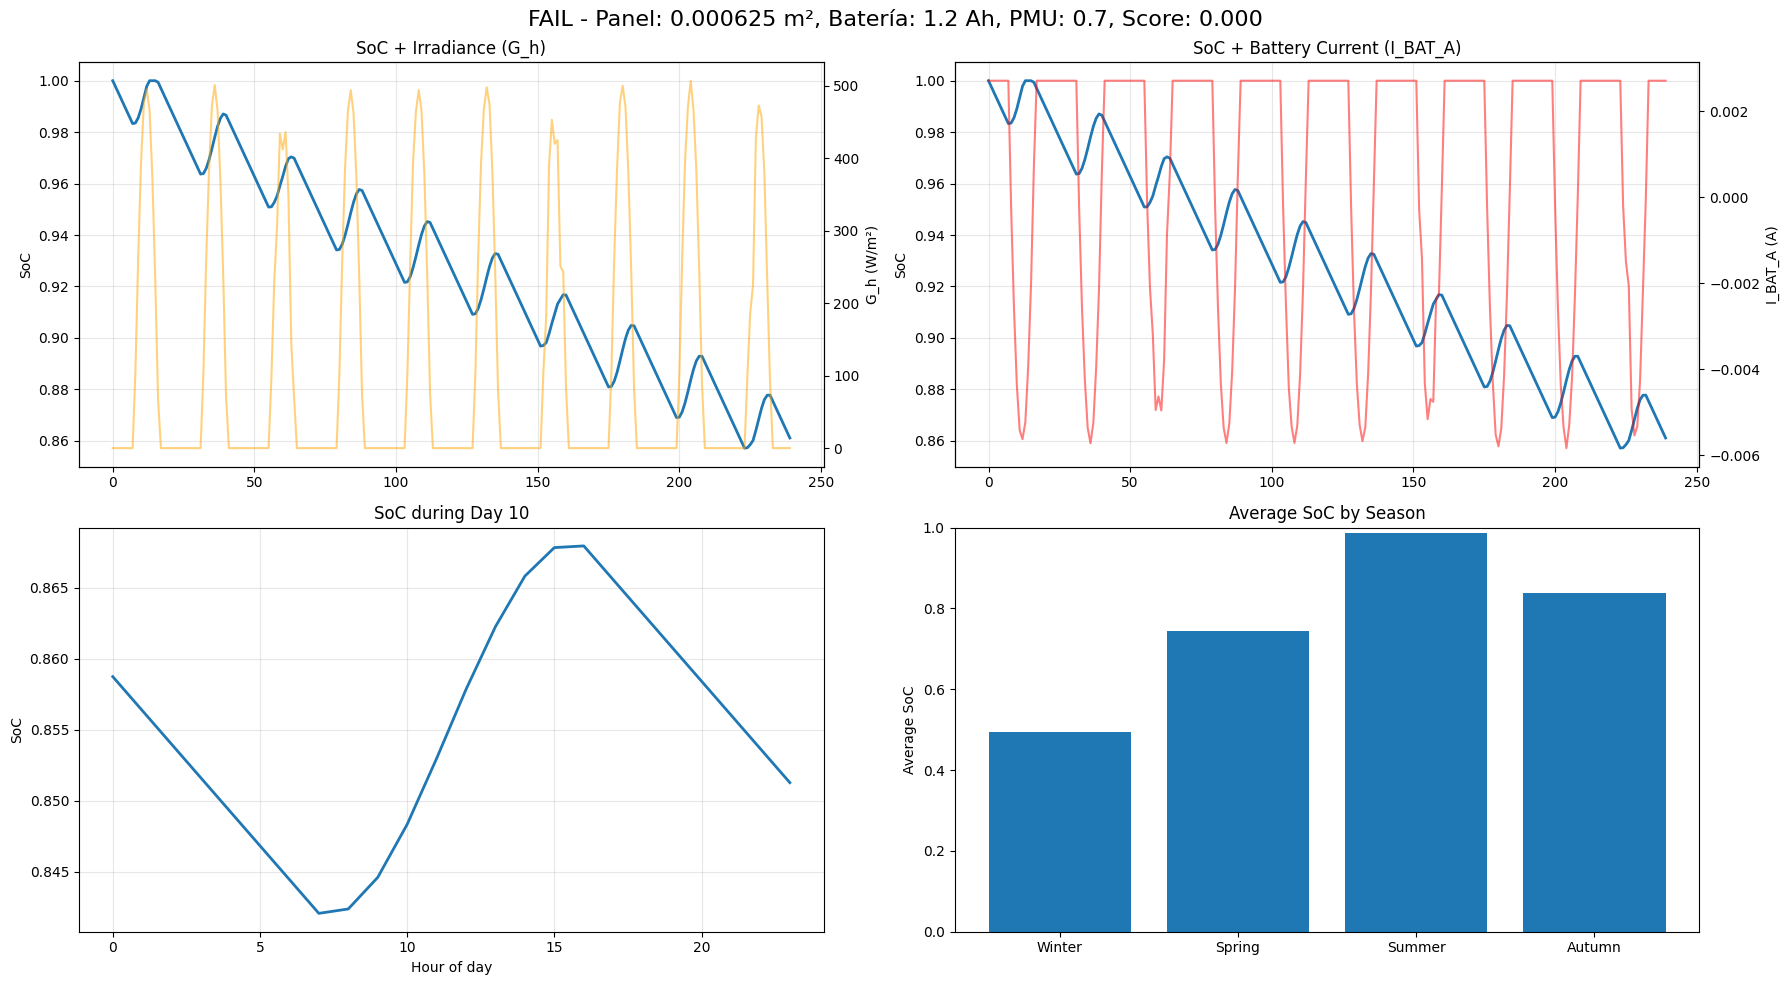

In [23]:
# === BEST SCORE ===
plot_full_soc_analysis(
    title_best,
    df_soc, df_pv,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    hours=240,
    day_index=10
)

# === MID-SCORE (~0.5) ===
plot_full_soc_analysis(
    title_mid,
    df_soc, df_pv,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    hours=240,
    day_index=10
)

# === BAD NON-ZERO SCORE ===
plot_full_soc_analysis(
    title_bad,
    df_soc, df_pv,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    hours=240,
    day_index=10
)

# === FAILURE CASE ===
plot_full_soc_analysis(
    title_fail,
    df_soc, df_pv,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    hours=240,
    day_index=10
)


## Pareto front

In [24]:
# ── Compute Pareto front ────────────────────────────────────────────────────
pareto_objectives = [
    ("C_batt_Ah",        -1),
    ("panel_area_m2",    -1),
    ("soc_full_fraction", -1),
]

front = simulator.pareto_front(summary, pareto_objectives)

print(f"{len(front)} configurations on the Pareto front (out of "
      f"{(summary['failure_hours'] == 0).sum()} viable ones)\n")

for i, row in front.iterrows():
    print(f"--- Config #{i} ---")
    print(f"  Panel area  : {row['panel_area_m2']*1e4:.1f} cm²  ({row['panel_area_m2']} m²)")
    print(f"  Battery     : {row['C_batt_Ah']} Ah")
    print(f"  η_PMU       : {row['eta_PMU']}")
    print(f"  SoC full    : {row['soc_full_fraction']*100:.1f}%")
    print(f"  Autonomy    : {row['autonomy_hours']} h")
    print(f"  Failures    : {int(row['failure_hours'])} h")
    print()


10 configurations on the Pareto front (out of 2470 viable ones)

--- Config #0 ---
  Panel area  : 6.2 cm²  (0.000625 m²)
  Battery     : 0.25 Ah
  η_PMU       : 0.85
  SoC full    : 22.2%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #1 ---
  Panel area  : 4.0 cm²  (0.0004 m²)
  Battery     : 0.35 Ah
  η_PMU       : 0.98
  SoC full    : 19.5%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #2 ---
  Panel area  : 4.0 cm²  (0.0004 m²)
  Battery     : 0.5 Ah
  η_PMU       : 0.95
  SoC full    : 17.6%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #3 ---
  Panel area  : 4.0 cm²  (0.0004 m²)
  Battery     : 1.1 Ah
  η_PMU       : 0.9
  SoC full    : 14.8%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #4 ---
  Panel area  : 4.0 cm²  (0.0004 m²)
  Battery     : 1.2 Ah
  η_PMU       : 0.87
  SoC full    : 12.8%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #5 ---
  Panel area  : 4.0 cm²  (0.0004 m²)
  Battery     : 1.6 Ah
  η_PMU       : 0.8

# Compute score from Pareto front¶
Pareto front¶

In [25]:
# Objectives for scoring
score_objectives = [
    ("soc_mean",     0.4),
    ("surplus_Ah",   0.4),
    ("eta_PMU",      0.2),
]


score = simulator.compute_score(front, score_objectives)

# columnas a mostrar
cols = [
    "panel_area_m2",
    "C_batt_Ah",
    "soc_full_fraction",
    "eta_PMU",
    "soc_mean",
    "soc_std",
    "surplus_Ah",
    "deficit_Ah",
    "hours_soc_full",
    "score",
]

tabla = score[cols]

# función para formatear valores
def fmt(v):
    if isinstance(v, float):
        return f"{v:.5f}"
    return str(v)

# calcular ancho máximo de cada columna
widths = []
for col in tabla.columns:
    max_data = tabla[col].map(fmt).map(len).max()
    widths.append(max(max_data, len(col)))

# encabezado
header = "  ".join(col.ljust(w) for col, w in zip(tabla.columns, widths))
print(header)

# línea separadora
print("-" * len(header))

# filas
for _, row in tabla.iterrows():
    line = "  ".join(fmt(v).ljust(w) for v, w in zip(row, widths))
    print(line)


panel_area_m2  C_batt_Ah  soc_full_fraction  eta_PMU  soc_mean  soc_std  surplus_Ah  deficit_Ah  hours_soc_full  score  
------------------------------------------------------------------------------------------------------------------------
0.00063        0.25000    0.22180            0.85000  0.92600   0.07632  10.65520    29.20942    1943.00000      0.64420
0.00063        1.80000    0.11096            0.70000  0.83822   0.19298  13.07050    18.93732    972.00000       0.60670
0.00040        0.35000    0.19486            0.98000  0.92142   0.10477  9.39624     23.04891    1707.00000      0.58993
0.00040        1.10000    0.14829            0.90000  0.89949   0.13826  10.28942    18.94007    1299.00000      0.58173
0.00040        0.50000    0.17568            0.95000  0.91170   0.13355  9.71232     21.46058    1539.00000      0.58150
0.00040        1.60000    0.11518            0.85000  0.85670   0.17501  10.94077    16.57871    1009.00000      0.52270
0.00040        1.20000    0.1280

# Visualize SOC through year

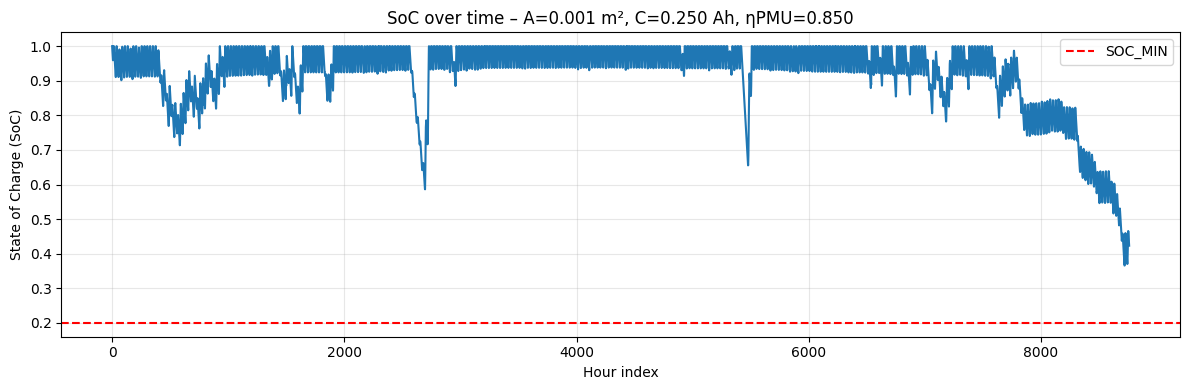

In [26]:
cfg = score.iloc[0]   # primera fila del DataFrame
plt.figure(figsize=(12, 4))
plt.plot(config_soc['hour_index'], config_soc['SoC'])

plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')

plt.xlabel('Hour index')
plt.ylabel('State of Charge (SoC)')
plt.title(
    f"SoC over time – A={cfg['panel_area_m2']:.3f} m², "
    f"C={cfg['C_batt_Ah']:.3f} Ah, ηPMU={cfg['eta_PMU']:.3f}"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()